# Módulo 3 — Rentabilidad y Eficiencia Bancaria
## Notebook 2: Análisis de Clustering y Benchmarking

---

**Objetivo:**  
Identificar perfiles de bancos con características similares de rentabilidad y eficiencia  
mediante clustering no supervisado (K-Means). El resultado es un **mapa de posicionamiento**  
del sector que permite a una entidad entender dónde se sitúa respecto a sus competidores.

**Input:** `datos/procesados/rentabilidad_bancos.csv`

---

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
df = pd.read_csv('../../datos/procesados/rentabilidad_bancos.csv')

# Usamos datos de 2023 para el clustering (snapshot más reciente)
df_2023 = df[df['anio'] == 2023].copy().dropna(subset=['roa', 'roe', 'nim', 'cir'])

print(f'✅ Dataset cargado: {len(df_2023):,} bancos (datos 2023)')

✅ Dataset cargado: 982 bancos (datos 2023)


## 2. Preparación de features para clustering

In [3]:
features = ['roa', 'roe', 'nim', 'cir']
X = df_2023[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features para clustering:', features)
print(f'Dimensiones: {X_scaled.shape}')

Features para clustering: ['roa', 'roe', 'nim', 'cir']
Dimensiones: (982, 4)


## 3. Número óptimo de clusters — Método del Codo + Silhouette

Antes de aplicar K-Means necesitamos decidir cuántos clusters (k) usar.  
Usamos dos métodos complementarios:
- **Método del codo:** busca el punto donde añadir más clusters deja de reducir significativamente la inercia
- **Silhouette score:** mide qué tan bien separados están los clusters (más alto = mejor)

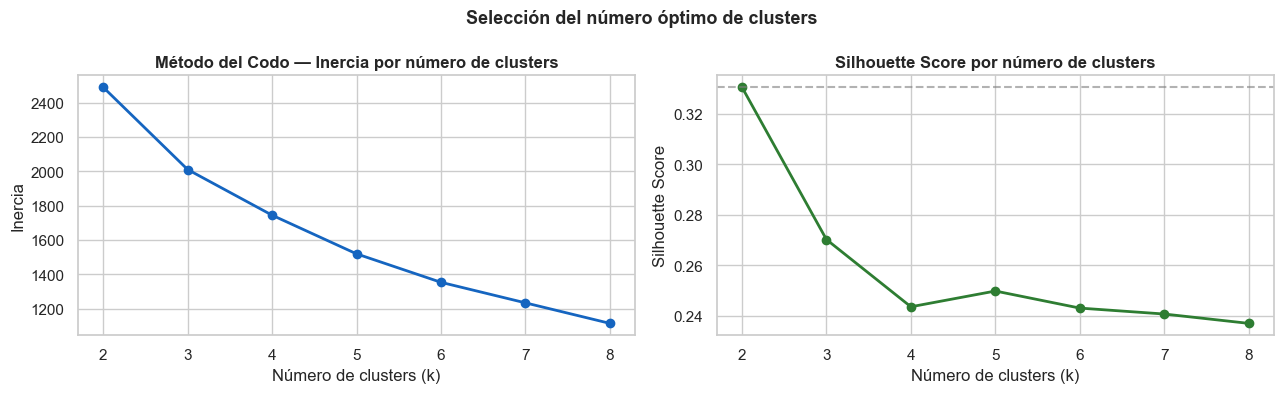

k óptimo por Silhouette: 2 (score: 0.331)


In [4]:
inercias    = []
silhouettes = []
rango_k     = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(rango_k, inercias, marker='o', color='#1565C0', lw=2)
axes[0].set_title('Método del Codo — Inercia por número de clusters', fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(rango_k, silhouettes, marker='o', color='#2E7D32', lw=2)
axes[1].set_title('Silhouette Score por número de clusters', fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axhline(y=max(silhouettes), color='gray', linestyle='--', alpha=0.6)

plt.suptitle('Selección del número óptimo de clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

k_optimo = list(rango_k)[silhouettes.index(max(silhouettes))]
print(f'k óptimo por Silhouette: {k_optimo} (score: {max(silhouettes):.3f})')

## 4. Aplicación de K-Means

In [5]:
# Usamos k=4 para obtener perfiles de negocio bien diferenciados
# (ajusta si el método del codo sugiere otro valor)
K = 4

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df_2023['cluster'] = km_final.fit_predict(X_scaled)

print(f'✅ K-Means aplicado con k={K}')
print(f'\nDistribución de bancos por cluster:')
print(df_2023['cluster'].value_counts().sort_index())

✅ K-Means aplicado con k=4

Distribución de bancos por cluster:
cluster
0    414
1    106
2    117
3    345
Name: count, dtype: int64


## 5. Caracterización de los clusters

Perfil mediano de cada cluster:
           roa     roe    nim     cir  n_bancos
cluster                                        
0        0.802   9.240  4.145  70.603       414
1        0.272   3.255  3.949  87.999       106
2        2.074  20.470  5.368  51.702       117
3        1.324  15.190  4.410  59.455       345


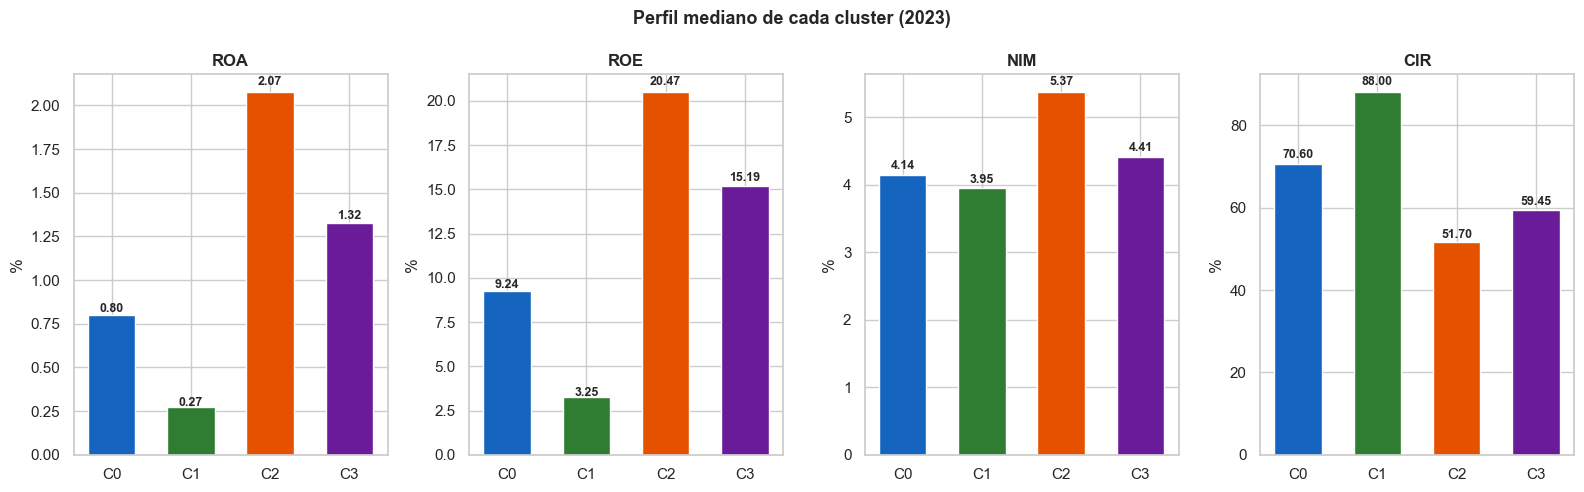

In [6]:
perfil = df_2023.groupby('cluster')[features].median().round(3)
perfil['n_bancos'] = df_2023['cluster'].value_counts().sort_index()

print('Perfil mediano de cada cluster:')
print(perfil.to_string())

# Visualización del perfil
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colores_cluster = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

for i, feat in enumerate(features):
    valores = perfil[feat].values
    bars = axes[i].bar([f'C{c}' for c in range(K)], valores,
                       color=colores_cluster, width=0.6)
    axes[i].set_title(feat.upper(), fontweight='bold', fontsize=12)
    axes[i].set_ylabel('%')
    for bar, val in zip(bars, valores):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     val + abs(val)*0.02,
                     f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Perfil mediano de cada cluster (2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Mapa de posicionamiento — PCA 2D

Reducimos las 4 dimensiones a 2 componentes principales para visualizar  
los clusters en un plano bidimensional — el "mapa del sector".

Varianza explicada — PC1: 64.7% · PC2: 21.9% · Total: 86.6%


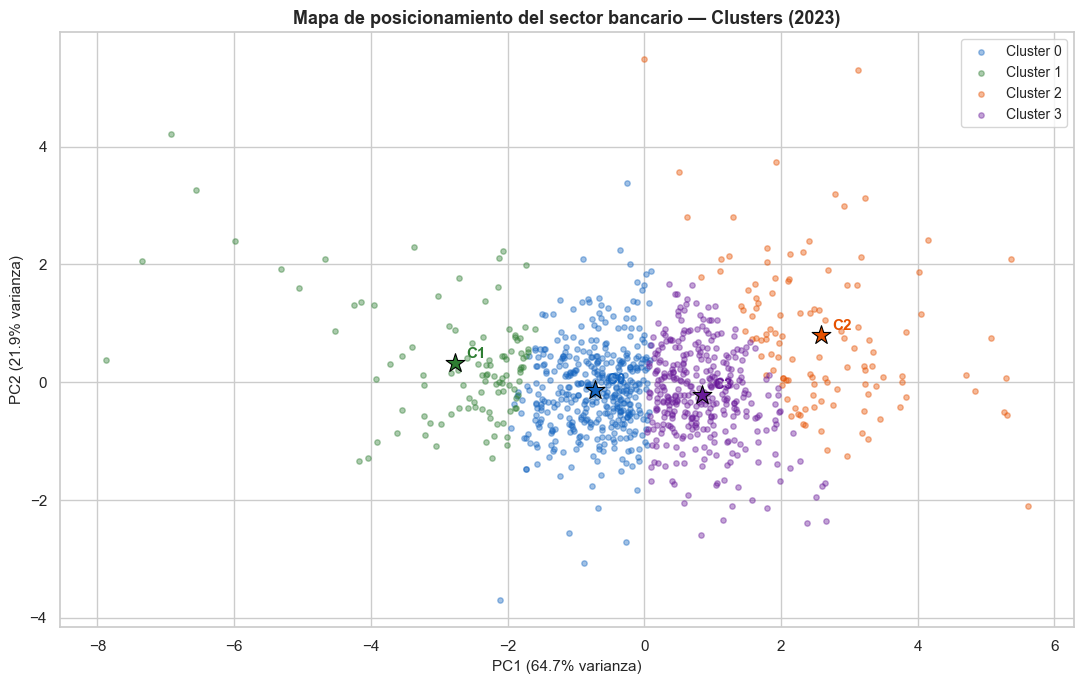

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print(f'Varianza explicada — PC1: {varianza[0]:.1%} · PC2: {varianza[1]:.1%} · Total: {sum(varianza):.1%}')

df_2023['pc1'] = X_pca[:, 0]
df_2023['pc2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))

for c, color in zip(range(K), colores_cluster):
    mask = df_2023['cluster'] == c
    ax.scatter(
        df_2023.loc[mask, 'pc1'],
        df_2023.loc[mask, 'pc2'],
        c=color, alpha=0.4, s=15, label=f'Cluster {c}'
    )

# Centroides
centroides_pca = pca.transform(km_final.cluster_centers_)
for c, color in zip(range(K), colores_cluster):
    ax.scatter(centroides_pca[c, 0], centroides_pca[c, 1],
               c=color, s=200, marker='*', edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(f'C{c}', (centroides_pca[c, 0], centroides_pca[c, 1]),
                textcoords='offset points', xytext=(8, 4),
                fontsize=11, fontweight='bold', color=color)

ax.set_xlabel(f'PC1 ({varianza[0]:.1%} varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({varianza[1]:.1%} varianza)', fontsize=11)
ax.set_title('Mapa de posicionamiento del sector bancario — Clusters (2023)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Composición de cada cluster por tamaño de banco

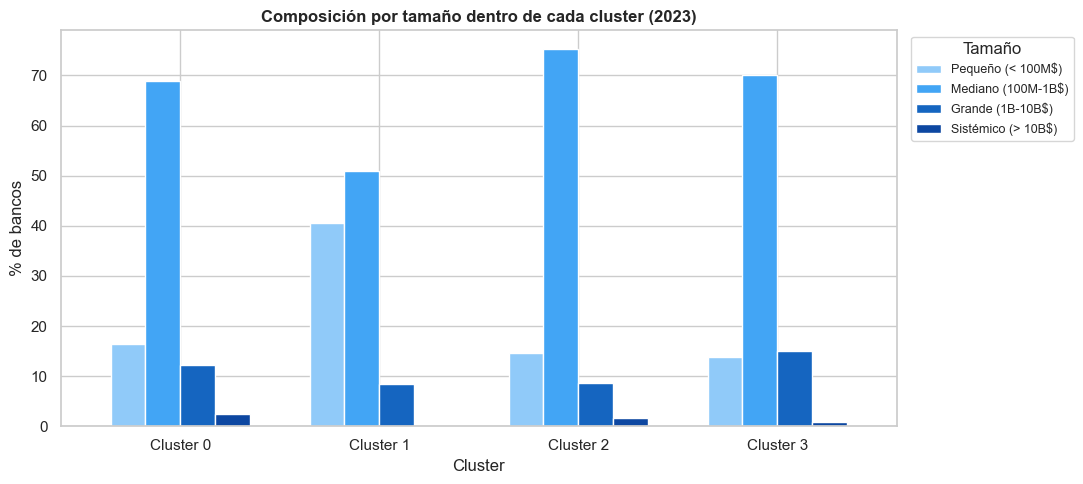

In [8]:
orden_tamano = ['Pequeño (< 100M$)', 'Mediano (100M-1B$)', 'Grande (1B-10B$)', 'Sistémico (> 10B$)']

composicion = df_2023.groupby(['cluster', 'tamano']).size().unstack(fill_value=0)
composicion = composicion.reindex(columns=orden_tamano, fill_value=0)
composicion_pct = composicion.div(composicion.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
colores_tamano = ['#90CAF9', '#42A5F5', '#1565C0', '#0D47A1']
composicion_pct.plot(kind='bar', ax=ax, color=colores_tamano, width=0.7)
ax.set_title('Composición por tamaño dentro de cada cluster (2023)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('% de bancos')
ax.set_xticklabels([f'Cluster {c}' for c in range(K)], rotation=0)
ax.legend(title='Tamaño', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Radar chart — Perfil de cada cluster

El radar chart permite visualizar simultáneamente las 4 dimensiones de cada perfil,  
facilitando la comparación entre clusters de un vistazo.

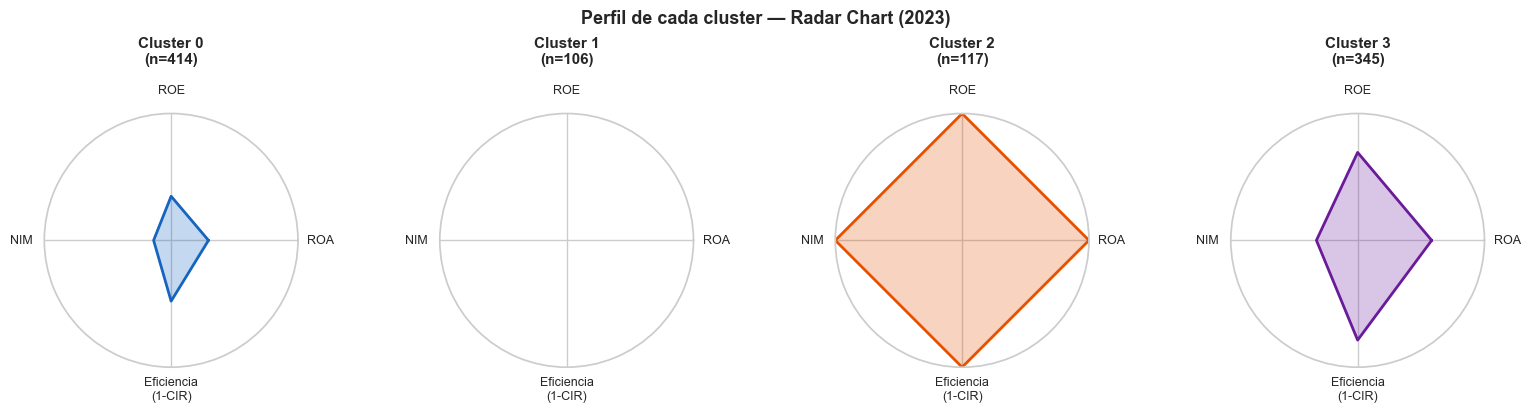

In [9]:
# Normalizar valores para el radar (0-1)
perfil_radar = df_2023.groupby('cluster')[features].median()
perfil_norm  = (perfil_radar - perfil_radar.min()) / (perfil_radar.max() - perfil_radar.min())
# Invertir CIR (menor es mejor)
perfil_norm['cir'] = 1 - perfil_norm['cir']

etiquetas = ['ROA', 'ROE', 'NIM', 'Eficiencia\n(1-CIR)']
N = len(etiquetas)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, axes = plt.subplots(1, K, figsize=(16, 4), subplot_kw=dict(polar=True))

for c, (ax, color) in enumerate(zip(axes, colores_cluster)):
    valores = perfil_norm.loc[c].values.tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, color=color, lw=2)
    ax.fill(angulos, valores, color=color, alpha=0.25)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(etiquetas, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    n = int(df_2023[df_2023['cluster']==c].shape[0])
    ax.set_title(f'Cluster {c}\n(n={n:,})', fontweight='bold', fontsize=11, pad=15)

plt.suptitle('Perfil de cada cluster — Radar Chart (2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Conclusiones del análisis

---

### Perfiles identificados por clustering

| Cluster | Perfil | ROA | ROE | NIM | CIR | n |
|---------|--------|-----|-----|-----|-----|---|
| C0 | **Banco medio del sector** | 0.80% | 9.24% | 4.15% | 70.6% | 414 |
| C1 | **Banco en dificultades** | 0.27% | 3.26% | 3.95% | 88.0% | 106 |
| C2 | **Banco de alto rendimiento** | 2.07% | 20.47% | 5.37% | 51.7% | 117 |
| C3 | **Banco eficiente y rentable** | 1.32% | 15.19% | 4.41% | 59.5% | 345 |

### Análisis de cada perfil

**Cluster 0 — Banco medio del sector (n=414, 42% del total)**  
El cluster más numeroso representa la banca típica americana. ROA de 0.80% y
CIR de 70.6% — por encima del umbral de eficiencia del 60%. Compuesto
mayoritariamente por bancos medianos (100M-1B$). Es el grupo de referencia
del sector: rentabilidad aceptable pero con margen claro de mejora en
eficiencia operativa.

**Cluster 1 — Banco en dificultades (n=106, 11% del total)**  
El perfil más preocupante. ROA de apenas 0.27% y CIR del 88% — por cada
100$ de ingresos, 88$ se van en costes operativos. El NIM de 3.95% es el
más bajo de todos los clusters, lo que sugiere una cartera crediticia poco
rentable. Compuesto por bancos pequeños y medianos. Estos bancos son
candidatos naturales a procesos de fusión o reestructuración.

**Cluster 2 — Banco de alto rendimiento (n=117, 12% del total)**  
El perfil élite del sector. ROA de 2.07%, ROE de 20.47% y CIR de 51.7% —
los mejores valores en todas las dimensiones simultáneamente. El NIM de
5.37% es significativamente superior al resto, lo que indica carteras
crediticias muy bien gestionadas o exposición a segmentos de mayor margen.
Predominan bancos medianos y grandes. Son el benchmark al que debería
aspirar cualquier entidad del sector.

**Cluster 3 — Banco eficiente y rentable (n=345, 35% del total)**  
El segundo grupo más numeroso y el más equilibrado. ROA de 1.32%, ROE de
15.19% y CIR de 59.5% — justo por debajo del umbral de eficiencia del 60%.
Compuesto principalmente por bancos medianos y grandes. Representa la
banca bien gestionada: no alcanza el nivel élite del C2, pero supera
claramente la media del sector en todas las dimensiones.

### Recomendaciones de negocio

1. **Para bancos del C0:** La palanca principal es la reducción del CIR —
   bajar del 70% al 60% requiere o bien aumentar ingresos o reducir costes
   operativos. La digitalización de procesos es la vía más habitual.
2. **Para bancos del C1:** Con un CIR del 88% la viabilidad a largo plazo
   es cuestionable. Se recomienda evaluar procesos de fusión con entidades
   del C3, que combinan eficiencia con escala suficiente para absorber
   costes fijos.
3. **Para bancos del C3:** El objetivo natural es migrar hacia el perfil C2.
   La diferencia clave está en el NIM (4.41% vs 5.37%) — mejorar la mezcla
   de cartera crediticia hacia segmentos de mayor margen es la palanca
   estratégica prioritaria.
4. **Benchmarking continuo:** El posicionamiento en el mapa PCA permite a
   cualquier entidad identificar visualmente su distancia a los clusters de
   mejor rendimiento y monitorizar su evolución año a año.

